# <center>**Fast-Reversion Limit of the Heston Model**</center>

This project presents an independent implementation of the 'Fast-reversion Heston' (FRH) model introduced by Mechkov (2015) (https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2418631). By taking the instantaneous variance mean-reversion speed to infinity, the paper attempts to deal with the classic drawbacks of the standard Heston model, such as inability to capture a strong volatility smile for shorter maturities, observed in the market data, or calibration ambiguity - larger variance volatility can be compensated by larger reversion speed. On the other hand, due to infinitely fast reversion, FRH is unable to capture volatility clustering observed in the empirical data.

The following reformulation of the Heston model is considered:
$$dx_t=-\frac{1}{2}z_t\sigma^2dt+\sigma\sqrt{z_t}dW^x_t$$
$$dz_t=a((1-z_t)dt+\gamma\sqrt{z_t}dW^z_t)$$
$$<dW^x_t,dW^z_t>=\rho dt,$$
where $x_t$ is a logarithmized price of a stock, $\sigma$ is its valatility, $z_t$ is a stochastic multiplier of this volatility, which reverts to 1, $\gamma$ is a volatility of this multiplier, and $a$ approaches infinity. This results in the following characteristic function of the log-price at maturity $x_T$:
$$\Phi_T(p)=E[e^{ipx_T}]=E[T\Lambda(p)],$$
where $\Lambda(p)$ is an infinitesmal generator:
$$\Lambda(p)=\gamma^{-2}(1 - i \rho \gamma \sigma p - \sqrt{(1 - i \rho \gamma \sigma p)^2 + (\gamma \sigma)^2 (p^2 + i p)}).$$

Interestingly, the normal inverse Gaussian (NIG) distribution has a characteristic function of a similar form. Parameters of this distrubution can be redefined using FRH's parameters, such that the exact same characteristic function as for FRH is obtained (see section 'Density function' below). NIG distribution has an explicitly given density funtion of the following form:
$$g(x;\alpha,\beta,\mu,\delta)=\frac{\alpha^2 \delta}{\pi} e^{\delta \sqrt{\alpha^2 - \beta^2}} e^{\beta (x - \mu)} \frac{K_1(\alpha \sqrt{\delta^2 + (x - \mu)^2})}{\alpha \sqrt{\delta^2 + (x - \mu)^2}},$$
where $K_1$ is the modified Bessel function of the second kind.

Given the explicit density function, the price of a European call option can be expressed as follows:
$$C(X)=S_0 \int_X^{+\infty} g(x;\alpha,\beta,\mu(T),\delta(T)) (e^x - e^X) dx,$$
where $X=ln(\frac{K}{S_0})-rT$. It can be also expressed using Fourier representation with integration going along the real axis:
$$C(X)=S_0 * \left(1 - \frac{e^{\frac{X}{2}}} {2 \pi} \int_{-\infty}^{+\infty} e^{- i X p} \frac{\Phi_T(p-\frac{i}{2})} {p^2 + \frac{1}{4}} dp \right)$$

Below we define the respective functions, price European call options under FRH using both methods described above, and compare them with prices obtained with a standard Black-Scholes formula. We also perform option pricing with a use of backward propagation. Finally, we obtain the implied volatility surface given by FRH.

In [21]:
import numpy as np
import pandas as pd
#import math
import cmath
from scipy.special import kn
from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import cm
from tabulate import tabulate
plt.rcParams["figure.figsize"] = (16,9)

#### Parametrization

In [22]:
sigma = 0.01
gamma = 0.415
rho = -0.5

In [23]:
S_0 = 10.0
K = 10.0
r = 0.02
T = 1.0

#### Characteristic function

In [24]:
i = complex(0, 1)
i

1j

In [25]:
def Lambda(sigma, gamma, rho, p):
    res = (gamma**(-2)) * (1 - i * rho * gamma * sigma * p - np.sqrt((1 - i * rho * gamma * sigma * p)**2 + ((gamma * sigma)**2) * (p**2 + i * p)))
    return res
def Phi(t, p):
    res = np.exp(t * Lambda(sigma, gamma, rho, p))
    return res

#### Density function

Below we define the parameters from NIG distribution with parameters from FRH. $\delta$ and $\mu$ are dependent on time to maturity here.

In [26]:
alpha = 0.5 * np.sqrt(4 - 4 * rho * gamma * sigma + (gamma**2) * (sigma**2)) / (gamma * sigma * (1 - rho**2))
beta = - 0.5 * (gamma * sigma - 2 * rho) / (gamma * sigma * (1 - rho**2))
def delta(t):
    res = t * sigma / gamma * np.sqrt(1 - rho **2)
    return res
def mu(t): 
    res = - t * sigma / gamma * rho
    return res

In [27]:
def g(x, t): 
    res = (alpha**2) * delta(t) / np.pi * np.exp(delta(t) * np.sqrt(alpha**2 - beta**2)) * np.exp(beta * (x - mu(t))) * kn(1, alpha * np.sqrt((delta(t)**2) + (x - mu(t))**2)) / (alpha * np.sqrt((delta(t)**2) + (x - mu(t))**2))
    return res
#np.array([[g(k, j) for k in xs] for j in ts]).reshape(100, 5000)

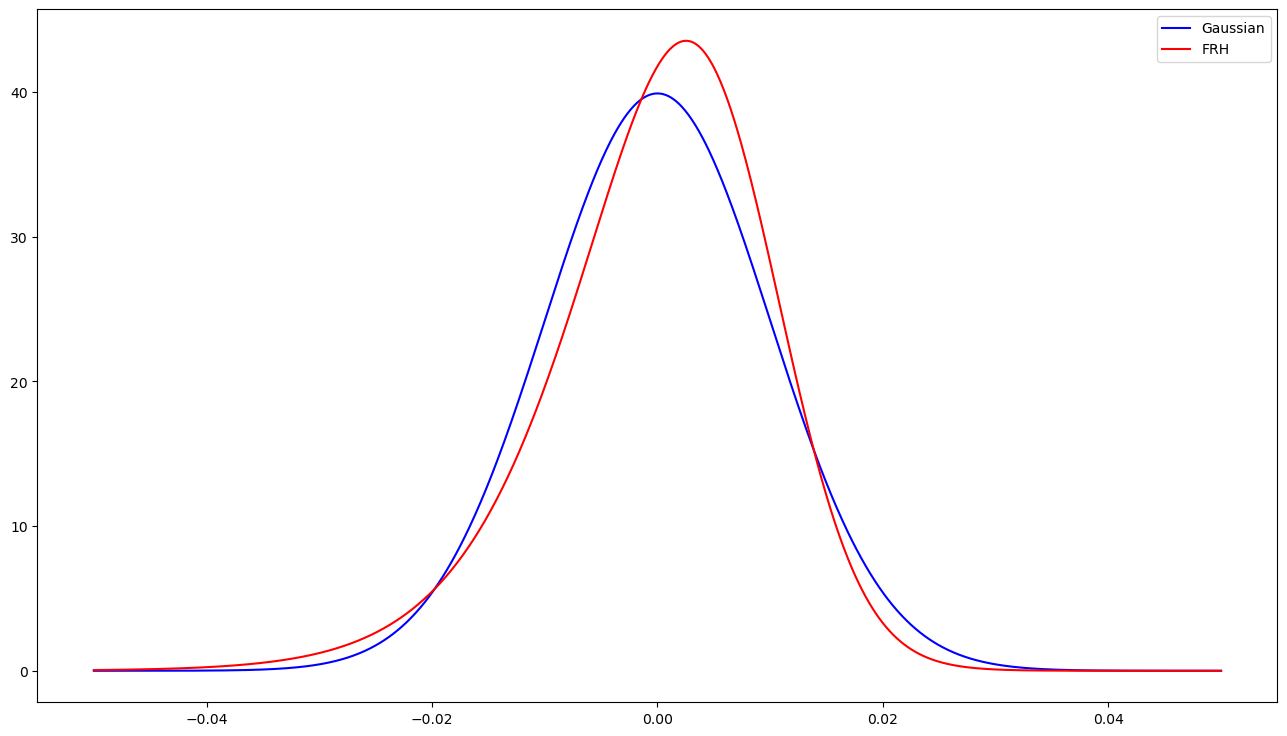

In [28]:
plt.plot(np.linspace(-0.05, 0.05, 1000), norm.pdf(np.linspace(-0.05, 0.05, 1000), 0, sigma), 'b', label = "Gaussian")
plt.plot(np.linspace(-0.05, 0.05, 1000), g(np.linspace(-0.05, 0.05, 1000), T), 'r', label = "FRH")
plt.legend()
plt.show()

#### European call option pricing with closed-form formulas

Pricing with a use of density function:

In [29]:
def C(S_0, K, r, T, t):
    X = np.log(K / S_0) - r * (T - t)
    res = S_0 * sum([((np.exp(x) - np.exp(X)) * g(x, T-t)) * (3.0 - X) / 10000 for x in np.linspace(X, 3.0, 10000)])
    return res

Pricing with a use of Fourier representation:

In [55]:
def C_F(S_0, K, r, T, t):
    X = np.log(K / S_0) - r * (T - t)
    res = S_0 * (1 - np.exp(X / 2) / (2 * np.pi) * sum([(np.exp(- i * X * p) * Phi(T - t, p - i / 2) / (p**2 + 0.25)).real * 0.001 for p in np.linspace(-200., 200., 400000)]))
    return res

In [56]:
C(S_0, K, r, T, 0), C_F(S_0, K, r, T, 0)

(0.20026105801178376, 0.20058061020862272)

Standard Black-Scholes model:

In [40]:
def BS_formula(S_0, K, r, sigma, T):
    d_1 = (np.log(S_0 / K) + (r + sigma ** 2 / 2) * T) / (sigma * np.sqrt(T))
    d_2 = d_1 - sigma * np.sqrt(T)
    return S_0 * norm.cdf(d_1) - K * np.exp(-r * T) * norm.cdf(d_2)

In [41]:
BS_formula(S_0, K, r, sigma, T)

0.1988538805418809

In [43]:
Kk = np.array([np.linspace(9.9, 10.1, 7)])
C_den = C(S_0, Kk, r, T, 0)
C_Fou = C_F(S_0, Kk, r, T, 0)
C_BS = BS_formula(S_0, Kk, r, sigma, T)
table = np.concatenate((Kk, C_den, C_Fou, C_BS))
print(tabulate(table))

--------  --------  --------  ---------  ---------  ---------  ---------
9.9       9.93333   9.96667   10         10.0333    10.0667    10.1
0.296455  0.264113  0.231999   0.200261   0.169128   0.138947   0.110216
0.296651  0.264527  0.232484   0.200605   0.169158   0.138634   0.10972
0.29607   0.263476  0.231014   0.198854   0.167304   0.136858   0.108205
--------  --------  --------  ---------  ---------  ---------  ---------


#### European call option pricing with a use of backward propagation

In [44]:
ts = np.linspace(0, T, 101)
dt = T / 100
dx = r * dt
xs = np.linspace(-400*dx, 400*dx, 801)
b = np.zeros([101, 801])

In [45]:
b[-1, :] = np.maximum(np.exp(xs) - K / S_0, 0)
for j in range(650,801):
    b[:, j] = np.exp((j-400)*dx) - K / S_0 * np.exp(- r * (T - ts))

In [46]:
%%time
for s in reversed(range(0,100)):
    for k in reversed(range(150,650)):
        b[s, k] = np.exp(-r*dt) * b[s+1, k+1] + sum([g(xs[l] - xs[k], dt) * (b[s+1, l] - b[s+1, l]) * dx for l in range(0,801)])

CPU times: total: 12min 3s
Wall time: 12min 8s


Price:

In [47]:
S_0 * b[0,400]

0.19801326693244695

#### Volatility surface

In [48]:
def vega(S_0, K, r, sigma, T):
    d_1 = (np.log(S_0 / K) + (r + sigma ** 2 / 2) * T) / (sigma * np.sqrt(T))
    res = (1 / np.sqrt(2 * np.pi)) * S_0 * np.sqrt(T) * np.exp(-(norm.cdf(d_1) ** 2) * 0.5)
    return res

In [49]:
def implied_vol(S_0, K, r, T, C, sigma, tol):
    sig_imp = sigma
    sig_imp_0 = sig_imp - 1
    C_imp = BS_formula(S_0, K, r, sig_imp, T)
    n = 0
    while abs(C - C_imp) > tol:
        sig_imp_0 = sig_imp
        C_imp = BS_formula(S_0, K, r, sig_imp, T)
        vega_imp = vega(S_0, K, r, sig_imp, T)
        d_sig = (C - C_imp) / vega_imp
        if n <= 20:
            sig_imp += d_sig
        elif n <= 100:
            sig_imp += 0.1*d_sig
        else:
            sig_imp += 0.01*d_sig
        n += 1
    return sig_imp

In [57]:
implied_vol(S_0, K, r, T, C(S_0, K, r, T, 0), sigma, 0.000001), implied_vol(S_0, K, r, T, C_F(S_0, K, r, T, 0), sigma, 0.000001)

(0.011888724030290372, 0.012209551853223687)

In [51]:
Ks = np.linspace(9.9, 10.1, 50)
Ts = np.linspace(0.05, 2.0, 50)
imp_vol_surface = np.zeros([50, 50])

In [52]:
%%time
for s in range(0,50):
    for l in range(0,50):
        imp_vol_surface[s, l] = implied_vol(S_0, Ks[l], r, Ts[s], C(S_0, Ks[l], r, Ts[s], 0), sigma, 0.000001)

CPU times: total: 25min 2s
Wall time: 25min 42s


In [54]:
%matplotlib qt
matu, strike = np.meshgrid(Ts, Ks)
ax = plt.axes(projection = '3d')
ax.plot_surface(np.log(strike / S_0), matu, imp_vol_surface.T, cmap = cm.coolwarm)
ax.set_title('Volatility surface')
plt.xlabel("ln(Stike/Spot)")
plt.ylabel("Maturity")
ax.set_zlabel("Implied volatility")
plt.show()